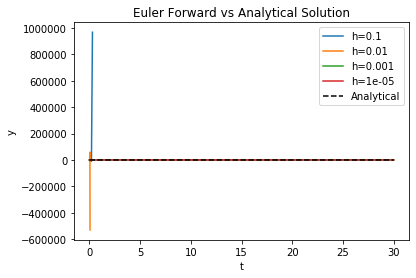

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

def analytical(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

h_values = [0.1, 0.01, 0.001, 0.00001]

t_start = 0
t_end = 30
y0 = 0

plt.figure()

for h in h_values:
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(1, len(t)):
        y[i] = y[i-1] + h * f(t[i-1], y[i-1])

        if abs(y[i]) > 1e6:
            y[i:] = np.nan
            break

    plt.plot(t, y, label=f"h={h}")

t_exact = np.linspace(t_start, t_end, 500)
y_exact = analytical(t_exact)

plt.plot(t_exact, y_exact, 'k--', label="Analytical")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Euler Forward vs Analytical Solution")
plt.legend(loc="upper right")

plt.show()